# 01 — Análise Descritiva dos Dados

**Mineração de Dados Aplicada à Predição de Inadimplência em Clientes de Cartão de Crédito**  
UPE — Escola Politécnica de Pernambuco

Este notebook produz as estatísticas e as figuras da **Seção 3.3** do artigo. Base: *Default of Credit Card Clients* (UCI, 30.000 registros, Taiwan, abril–setembro de 2005).

Etapas: integridade → distribuição do alvo → variáveis quantitativas → variáveis categóricas → histórico de pagamento e correlações.

In [ ]:
# ---------------------------------------------------------------------------
# Setup — funciona local, no Google Colab e no Kaggle.
# Se estiver rodando fora do repositório, o bloco abaixo faz o clone.
# ---------------------------------------------------------------------------
import os, sys, subprocess

REPO_URL = "https://github.com/VictorJCFerreira/inadimplencia-cartao-credito.git"
REPO_DIR = "inadimplencia-cartao-credito"

def localizar_raiz():
    # Sobe até encontrar a pasta data/raw (execução dentro do repositório)
    d = os.path.abspath(os.getcwd())
    for _ in range(4):
        if os.path.isdir(os.path.join(d, "data", "raw")):
            return d
        d = os.path.dirname(d)
    return None

raiz = localizar_raiz()
if raiz is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    raiz = os.path.abspath(REPO_DIR)
os.chdir(raiz)
sys.path.insert(0, os.path.join(raiz, "src"))
print("Raiz do projeto:", raiz)

RAW_PATH = os.path.join("data", "raw", "default_of_credit_card_clients.xls")
assert os.path.exists(RAW_PATH), (
    "Base bruta não encontrada. Baixe 'default of credit card clients.xls' do "
    "repositório da UCI (https://doi.org/10.24432/C55S3H) e salve em data/raw/."
)


Raiz do projeto: /home/claude/proj/repo


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
RANDOM_STATE = 42
TARGET = "default payment next month"


## Carga da base bruta

O arquivo original da UCI traz cabeçalho em duas linhas (X1..X23 na primeira, os nomes das variáveis na segunda) — daí `header=1`.

In [3]:
df = pd.read_excel(RAW_PATH, header=1).rename(columns={"PAY_0": "PAY_1"})
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dimensões: 30000 linhas x 25 colunas


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3.3.1 Integridade e completude

In [4]:
print("Valores ausentes na base:", int(df.isna().sum().sum()))
print("Registros duplicados (com ID):", int(df.duplicated().sum()))
print("Registros duplicados (sem ID):", int(df.drop(columns=["ID"]).duplicated().sum()))

Valores ausentes na base: 0
Registros duplicados (com ID): 0
Registros duplicados (sem ID): 35


## 3.3.2 Distribuição da variável-alvo (Figura 1)

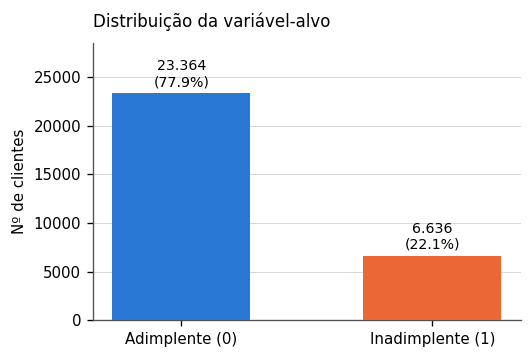

Razão entre classes: 3.52 : 1


In [5]:
C_ADIMP, C_INAD = "#2a78d6", "#eb6834"   # paleta validada p/ daltonismo
C_GRID, C_TEXT, C_MUTED = "#d8d7d2", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 120, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": C_MUTED, "figure.facecolor": "white"})

cont = df[TARGET].value_counts().sort_index()
pct = cont / len(df) * 100
fig, ax = plt.subplots(figsize=(4.6, 3.0))
ax.grid(axis="y", color=C_GRID, linewidth=0.6); ax.set_axisbelow(True)
bars = ax.bar(["Adimplente (0)", "Inadimplente (1)"], cont.values,
              color=[C_ADIMP, C_INAD], width=0.55, zorder=3)
for b, c, p in zip(bars, cont.values, pct.values):
    ax.text(b.get_x() + b.get_width()/2, c + 400, f"{c:,}\n({p:.1f}%)".replace(",", "."),
            ha="center", va="bottom", fontsize=8.5)
ax.set_ylabel("Nº de clientes"); ax.set_ylim(0, cont.max()*1.22)
ax.set_title("Distribuição da variável-alvo", fontsize=10, loc="left", pad=10)
plt.show()
print(f"Razão entre classes: {cont[0]/cont[1]:.2f} : 1")

O desbalanceamento (22,1% de inadimplentes) inviabiliza a acurácia como métrica: um classificador que respondesse sempre "adimplente" acertaria 77,9% sem identificar nenhum inadimplente.

## 3.3.3 Variáveis quantitativas e outliers (Figura 2)

In [6]:
display(df[["LIMIT_BAL", "AGE"]].describe().round(2))

for col in ["LIMIT_BAL", "AGE"]:
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (df[col] < lo) | (df[col] > hi)
    print(f"{col}: IQR={iqr:,.0f} | limites=({lo:,.1f}, {hi:,.1f}) | "
          f"outliers={int(mask.sum())} ({mask.mean()*100:.2f}%)")

,LIMIT_BAL,AGE
count,30000.00,30000.00
mean,167484.32,35.49
std,129747.66,9.22
min,10000.00,21.00
25%,50000.00,28.00
50%,140000.00,34.00
75%,240000.00,41.00
max,1000000.00,79.00


LIMIT_BAL: IQR=190,000 | limites=(-235,000.0, 525,000.0) | outliers=167 (0.56%)
AGE: IQR=13 | limites=(8.5, 60.5) | outliers=272 (0.91%)


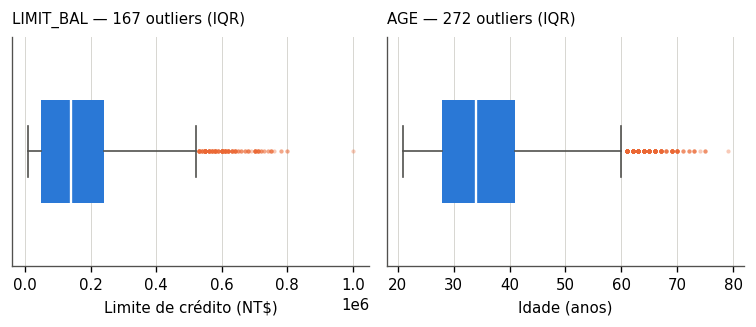

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))
for ax, col, label in zip(axes, ["LIMIT_BAL", "AGE"],
                          ["Limite de crédito (NT$)", "Idade (anos)"]):
    ax.grid(axis="x", color=C_GRID, linewidth=0.6); ax.set_axisbelow(True)
    ax.boxplot(df[col], vert=False, widths=0.45, patch_artist=True,
               flierprops=dict(marker="o", markersize=2.5, markerfacecolor=C_INAD,
                               markeredgecolor="none", alpha=0.35),
               medianprops=dict(color="white", linewidth=1.4),
               boxprops=dict(facecolor=C_ADIMP, edgecolor="none"),
               whiskerprops=dict(color=C_MUTED), capprops=dict(color=C_MUTED), zorder=3)
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3 - q1
    n_out = int(((df[col] < q1-1.5*iqr) | (df[col] > q3+1.5*iqr)).sum())
    ax.set_yticks([]); ax.set_xlabel(label)
    ax.set_title(f"{col} — {n_out} outliers (IQR)", fontsize=9, loc="left", pad=8)
plt.tight_layout(); plt.show()

Os valores atípicos são clientes de limite alto e de idade mais avançada — um subgrupo real da população, não erro de coleta. A decisão de mantê-los é justificada na Seção 3.4.1.

In [8]:
bill = [f"BILL_AMT{i}" for i in range(1, 7)]
display(df[bill].describe().loc[["mean", "std", "min", "50%", "max"]].round(1))
print("Células com fatura negativa:", int((df[bill] < 0).sum().sum()),
      "| clientes afetados:", int((df[bill] < 0).any(axis=1).sum()))
print("Células com fatura igual a zero:", int((df[bill] == 0).sum().sum()))

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
mean,51223.3,49179.1,47013.2,43262.9,40311.4,38871.8
std,73635.9,71173.8,69349.4,64332.9,60797.2,59554.1
min,-165580.0,-69777.0,-157264.0,-170000.0,-81334.0,-339603.0
50%,22381.5,21200.0,20088.5,19052.0,18104.5,17071.0
max,964511.0,983931.0,1664089.0,891586.0,927171.0,961664.0


Células com fatura negativa: 3932 | clientes afetados: 1930
Células com fatura igual a zero: 18105


Fatura negativa **não** é erro: indica saldo credor do cliente junto ao emissor (pagamento a maior ou estorno). Isso condiciona o cálculo da taxa de amortização na Seção 3.4.2.

## 3.3.4 Variáveis categóricas e consistência com o dicionário (Figura 3)

In [9]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(col, "->", df[col].value_counts().sort_index().to_dict())
print("\nEDUCATION fora do dicionário (0, 5, 6):", int(df.EDUCATION.isin([0,5,6]).sum()))
print("MARRIAGE fora do dicionário (0):", int((df.MARRIAGE == 0).sum()))

SEX -> {1: 11888, 2: 18112}
EDUCATION -> {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE -> {0: 54, 1: 13659, 2: 15964, 3: 323}

EDUCATION fora do dicionário (0, 5, 6): 345
MARRIAGE fora do dicionário (0): 54


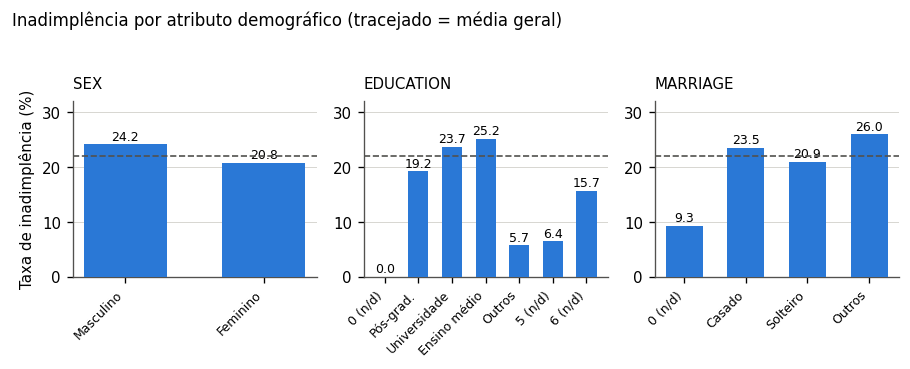

In [10]:
mapas = {"SEX": {1: "Masculino", 2: "Feminino"},
         "EDUCATION": {0: "0 (n/d)", 1: "Pós-grad.", 2: "Universidade",
                       3: "Ensino médio", 4: "Outros", 5: "5 (n/d)", 6: "6 (n/d)"},
         "MARRIAGE": {0: "0 (n/d)", 1: "Casado", 2: "Solteiro", 3: "Outros"}}
taxa_geral = df[TARGET].mean() * 100
fig, axes = plt.subplots(1, 3, figsize=(7.6, 2.9))
for ax, col in zip(axes, mapas):
    ax.grid(axis="y", color=C_GRID, linewidth=0.6); ax.set_axisbelow(True)
    g = df.groupby(col)[TARGET].agg(["count", "mean"])
    ax.bar([mapas[col].get(i, str(i)) for i in g.index], g["mean"]*100,
           color=C_ADIMP, width=0.6, zorder=3)
    ax.axhline(taxa_geral, color=C_MUTED, linewidth=1.0, linestyle="--", zorder=4)
    for i, v in enumerate(g["mean"]):
        ax.text(i, v*100 + 0.8, f"{v*100:.1f}", ha="center", fontsize=7.5)
    ax.set_title(col, fontsize=9, loc="left", pad=8); ax.set_ylim(0, 32)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7.5)
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")
axes[0].set_ylabel("Taxa de inadimplência (%)")
fig.suptitle("Inadimplência por atributo demográfico (tracejado = média geral)",
             fontsize=10, x=0.01, ha="left", y=1.04)
plt.tight_layout(); plt.show()

Os códigos não documentados de `EDUCATION` têm taxas próximas da categoria 4 ("outros") e distantes das categorias regulares — evidência que sustenta a consolidação feita na limpeza.

## 3.3.5 Histórico de pagamento e correlação com o alvo (Figuras 4 e 5)

,count,mean
PAY_1,,
-2,2759,0.1323
-1,5686,0.1678
0,14737,0.1281
1,3688,0.3395
2,2667,0.6914
3,322,0.7578
4,76,0.6842
5,26,0.5000
6,11,0.5455


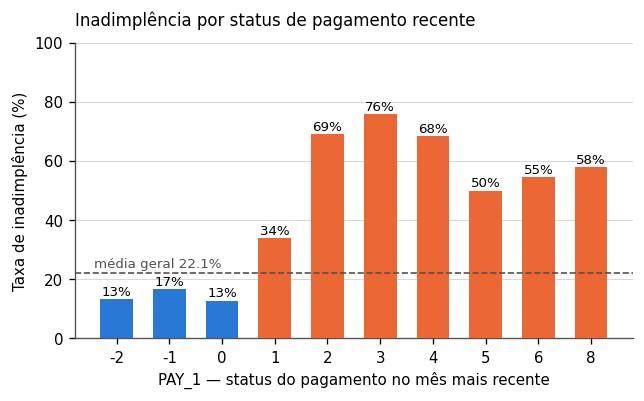

In [11]:
g = df.groupby("PAY_1")[TARGET].agg(["count", "mean"])
display(g.round(4))
g = g[g["count"] >= 10]
taxa_geral = df[TARGET].mean()
fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.grid(axis="y", color=C_GRID, linewidth=0.6); ax.set_axisbelow(True)
ax.bar(g.index.astype(str), g["mean"]*100,
       color=[C_INAD if v > taxa_geral else C_ADIMP for v in g["mean"]],
       width=0.62, zorder=3)
ax.axhline(taxa_geral*100, color=C_MUTED, linewidth=1.0, linestyle="--", zorder=4)
ax.text(-0.42, taxa_geral*100 + 2.0, f"média geral {taxa_geral*100:.1f}%",
        fontsize=8, color=C_MUTED, ha="left")
for i, v in enumerate(g["mean"]):
    ax.text(i, v*100 + 1.2, f"{v*100:.0f}%", ha="center", fontsize=8)
ax.set_xlabel("PAY_1 — status do pagamento no mês mais recente")
ax.set_ylabel("Taxa de inadimplência (%)"); ax.set_ylim(0, 100)
ax.set_title("Inadimplência por status de pagamento recente", fontsize=10, loc="left", pad=10)
plt.show()

Há descontinuidade nítida entre os códigos não positivos (13% a 17% de inadimplência) e o primeiro mês de atraso (34%), chegando a 69% com dois meses. Isso motiva a criação de `N_MESES_ATRASO` na Seção 3.4.2.

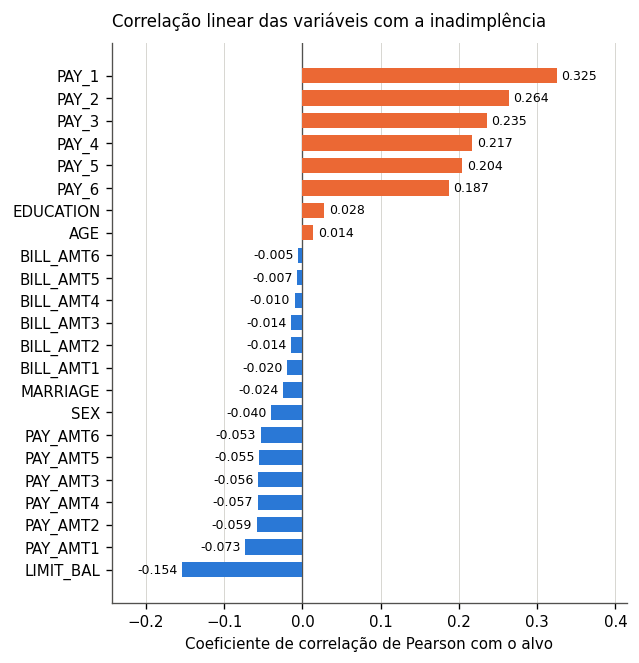

|r| < 0,02: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'AGE']


In [12]:
corr = df.drop(columns=["ID"]).corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(5.4, 5.6))
ax.grid(axis="x", color=C_GRID, linewidth=0.6); ax.set_axisbelow(True)
ax.barh(corr.index, corr.values,
        color=[C_INAD if v > 0 else C_ADIMP for v in corr.values], height=0.68, zorder=3)
ax.axvline(0, color=C_MUTED, linewidth=0.8)
for i, v in enumerate(corr.values):
    ax.text(v + (0.006 if v >= 0 else -0.006), i, f"{v:.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=7.5)
ax.set_xlim(corr.min()-0.09, corr.max()+0.09)
ax.set_xlabel("Coeficiente de correlação de Pearson com o alvo")
ax.set_title("Correlação linear das variáveis com a inadimplência",
             fontsize=10, loc="left", pad=10)
plt.tight_layout(); plt.show()

print("|r| < 0,02:", list(corr[corr.abs() < 0.02].index))

As seis variáveis de status de pagamento lideram a correlação, decrescendo conforme o mês se afasta do período de predição. As variáveis de fatura têm correlação praticamente nula — o que motiva a criação de `AVG_UTIL_RATIO` (fatura relativa ao limite) em vez do valor absoluto.

---

**Próximo passo:** `02_preprocessamento.ipynb`, que implementa as decisões de limpeza, transformação e redução justificadas por esta análise.